# Indicador Criança Alfabetizada — Análise, KPIs e Modelo de Risco

**Tech Challenge Fase 2 — Camada Gold**

Este notebook parte diretamente das 4 tabelas Gold do pipeline (`analiticos`, `evolucao_temporal`, `indicador_municipio`, `trajetoria_meta_2030`) e faz três coisas:

1. **KPIs** — visão geral do indicador de alfabetização, por região/UF e por infraestrutura escolar
2. **Modelo de classificação** — Random Forest (+ baseline Logistic Regression) para classificar o `risco` associado à trajetória dos municípios rumo à meta de 2030
3. **Clustering** — K-Means para identificar perfis de vulnerabilidade educacional

O notebook utiliza exclusivamente dados já preparados na camada Gold.


## 1. Setup e carga dos dados

In [87]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, silhouette_score
)
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42

In [64]:
# Raiz do projeto
def encontrar_raiz(marcador: str = "pyproject.toml") -> Path:
    atual = Path.cwd().resolve()
    for pasta in [atual, *atual.parents]:
        if (pasta / marcador).exists():
            return pasta
    raise FileNotFoundError(
        f"Nao encontrei '{marcador}' subindo a partir de {atual}. "
        "Rode o notebook a partir de dentro do repositorio."
    )

ROOT = encontrar_raiz()
GOLD_DIR = ROOT / "data" / "model" / "gold"
ASSETS_DIR = ROOT / "assets" / "imagens"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Raiz do projeto:", ROOT)
print("Gold:", GOLD_DIR)
print("Gold existe?", GOLD_DIR.exists())

Raiz do projeto: C:\Users\devil\fiap-ai-scientist-fase-02_\fiap-ai-scientist-fase-02_
Gold: C:\Users\devil\fiap-ai-scientist-fase-02_\fiap-ai-scientist-fase-02_\data\model\gold
Gold existe? True


In [65]:
# Caminhos das tabelas Gold
features_path = GOLD_DIR / "analiticos" / "features_municipio"
indicador_path = GOLD_DIR / "indicadores" / "indicador_municipio"
evolucao_path = GOLD_DIR / "indicadores" / "evolucao_temporal"
trajetoria_path = GOLD_DIR / "indicadores" / "trajetoria_meta_2030"

# Leitura dos Parquets
df_features = pd.read_parquet(features_path)
df_indicador = pd.read_parquet(indicador_path)
df_evolucao = pd.read_parquet(evolucao_path)
df_trajetoria = pd.read_parquet(trajetoria_path)

print("Features:", df_features.shape)
print("Indicador municipio:", df_indicador.shape)
print("Evolucao temporal:", df_evolucao.shape)
print("Trajetoria 2030:", df_trajetoria.shape)

Features: (5500, 24)
Indicador municipio: (23995, 22)
Evolucao temporal: (10896, 13)
Trajetoria 2030: (5500, 13)


## 2. KPIs — visão geral nacional

Indicadores de alto nível para abrir a análise, no mesmo formato que o README já reporta.

In [66]:
# KPIs — visão geral nacional
total_municipios = df_features["id_municipio"].nunique()
elegiveis = df_features["elegivel_meta"].sum()
atingiram_2024 = df_features["alvo_atingiu_meta"].sum()

pct_atingiram = (
    atingiram_2024
    / df_features["alvo_atingiu_meta"].notna().sum()
    * 100
)

taxa_media_2023 = df_features["taxa_2023"].mean()
taxa_media_2024 = df_features["alvo_taxa_2024"].mean()

print(f"Total de municípios:              {total_municipios:}")
print(f"Municípios elegíveis para meta:    {elegiveis:.0f}")
print(f"% que atingiram a meta em 2024:    {pct_atingiram:.1f}%")
print(f"Taxa média de alfabetização 2023:  {taxa_media_2023:.1f}%")
print(f"Taxa média de alfabetização 2024:  {taxa_media_2024:.1f}%")
print(f"Variação média nacional:            {taxa_media_2024 - taxa_media_2023:+.1f} p.p.")

Total de municípios:              5500
Municípios elegíveis para meta:    5232
% que atingiram a meta em 2024:    53.3%
Taxa média de alfabetização 2023:  60.3%
Taxa média de alfabetização 2024:  62.8%
Variação média nacional:            +2.5 p.p.


In [67]:

dist_trajetoria = df_trajetoria["classificacao_trajetoria"].value_counts()
dist_trajetoria_pct = (dist_trajetoria / dist_trajetoria.sum() * 100).round(1)

kpi_trajetoria = pd.DataFrame({
    "municipios": dist_trajetoria,
    "pct": dist_trajetoria_pct
}).sort_values("municipios", ascending=False)

kpi_trajetoria


,municipios,pct
classificacao_trajetoria,,
retrocesso,1917,34.9
em_ritmo,1704,31.0
meta_atingida,1147,20.9
ritmo_insuficiente,536,9.7
sem_meta,196,3.6


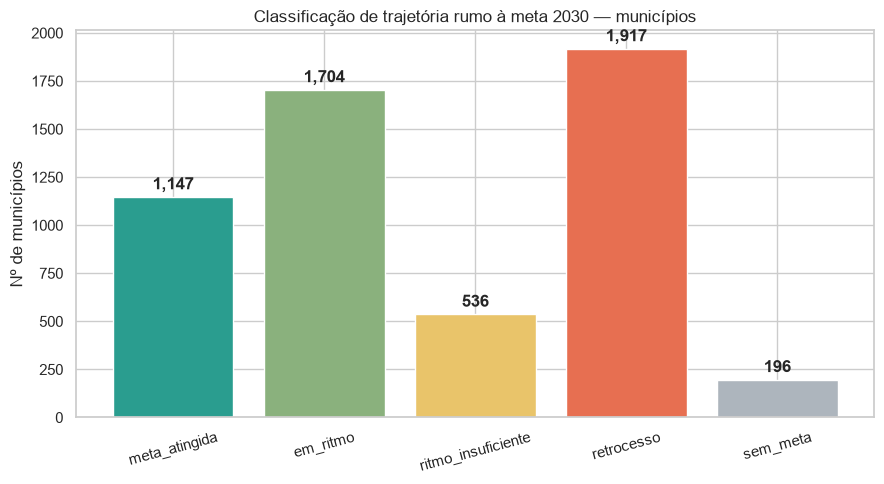

In [ ]:

ordem = ["meta_atingida", "em_ritmo", "ritmo_insuficiente", "retrocesso", "sem_meta"]
cores = {"meta_atingida": "#2a9d8f", "em_ritmo": "#8ab17d", "ritmo_insuficiente": "#e9c46a",
         "retrocesso": "#e76f51", "sem_meta": "#adb5bd"}

ordem_presente = [c for c in ordem if c in kpi_trajetoria.index]
fig, ax = plt.subplots()
valores = kpi_trajetoria.loc[ordem_presente, "municipios"]
ax.bar(ordem_presente, valores, color=[cores[c] for c in ordem_presente])
for i, v in enumerate(valores):
    ax.text(i, v + 40, f"{v:,}", ha="center", fontweight="bold")
ax.set_title("classificacao-trajetoria-meta-2030")
ax.set_ylabel("Nº de municípios")
plt.xticks(rotation=15)
plt.tight_layout()
# plt.savefig(ASSETS_DIR / "calssificacao_trajetoria_rumo_meta_2030")
plt.show()


### 2.1 KPI por região

In [69]:

kpi_regiao = df_features.groupby("regiao").agg(
    municipios=("id_municipio", "nunique"),
    taxa_media_2023=("taxa_2023", "mean"),
    taxa_media_2024=("alvo_taxa_2024", "mean"),
    indice_infra_medio=("indice_infraestrutura", "mean"),
).round(1)
kpi_regiao["variacao_p.p."] = (kpi_regiao["taxa_media_2024"] - kpi_regiao["taxa_media_2023"]).round(1)
kpi_regiao = kpi_regiao.sort_values("taxa_media_2024", ascending=False)
kpi_regiao


,municipios,taxa_media_2023,taxa_media_2024,indice_infra_medio,variacao_p.p.
regiao,,,,,
Centro-Oeste,465,64.5,72.3,79.0,7.8
Sudeste,1635,62.2,70.0,86.0,7.8
Sul,1172,72.2,63.8,84.1,-8.4
Nordeste,1793,53.1,56.3,69.2,3.2
Norte,435,45.8,49.4,63.5,3.6


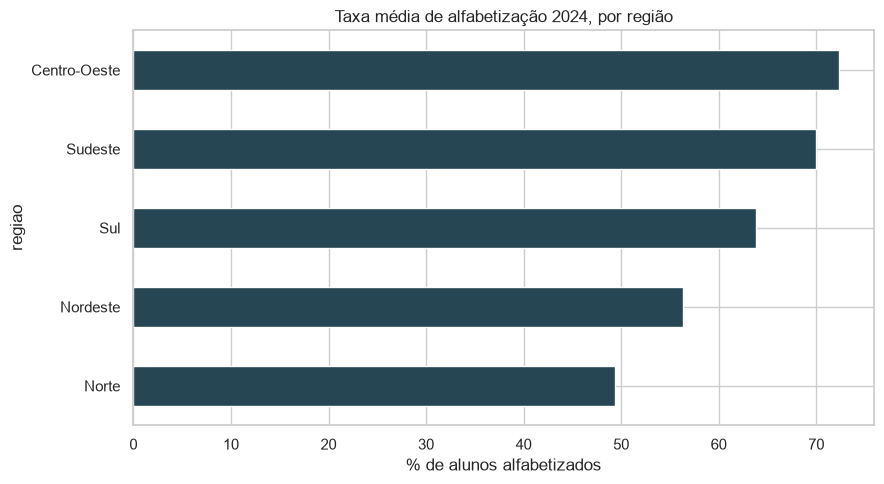

In [ ]:

fig, ax = plt.subplots()
kpi_regiao["taxa_media_2024"].sort_values().plot(kind="barh", ax=ax, color="#264653")
ax.set_title("Taxa média de alfabetização 2024, por região")
ax.set_xlabel("% de alunos alfabetizados")
plt.tight_layout()
# plt.savefig(ASSETS_DIR / "taxa-media-alfabetizacao-2024-regiao")
plt.show()


### 2.2 Infraestrutura x resultado — o achado que já está no README

Agrupando municípios por quartil do índice de infraestrutura escolar, a taxa de alfabetização sobe de forma consistente — reproduzindo aqui a tabela já reportada.

In [71]:

df_features["quartil_infra"] = pd.qcut(
    df_features["indice_infraestrutura"], 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"]
)

kpi_infra = df_features.groupby("quartil_infra", observed=True).agg(
    indice_medio=("indice_infraestrutura", "mean"),
    taxa_media=("alvo_taxa_2024", "mean"),
    alunos_por_docente=("alunos_por_docente", "mean"),
).round(1)
kpi_infra


,indice_medio,taxa_media,alunos_por_docente
quartil_infra,,,
Q1 (menor),58.5,57.7,17.8
Q2,73.4,60.6,17.5
Q3,83.4,66.0,15.8
Q4 (maior),96.3,67.0,14.9


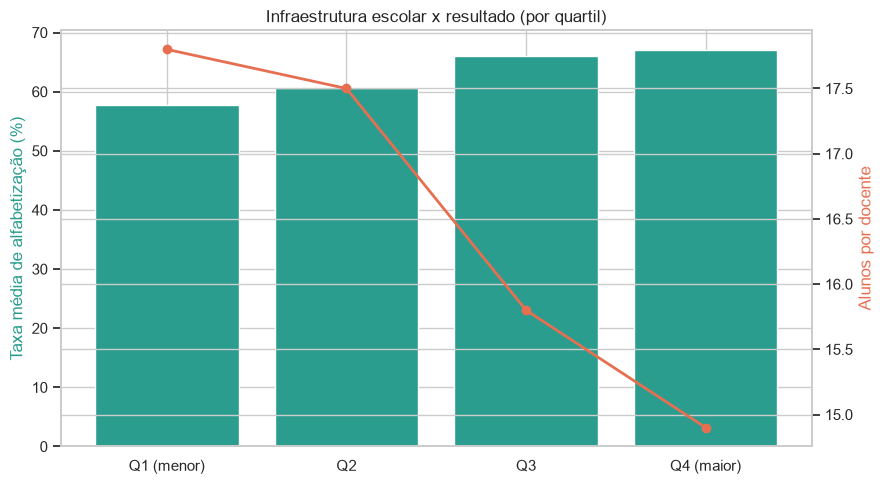

In [ ]:

fig, ax1 = plt.subplots()
ax1.bar(kpi_infra.index.astype(str), kpi_infra["taxa_media"], color="#2a9d8f")
ax1.set_ylabel("Taxa média de alfabetização (%)", color="#2a9d8f")
ax1.set_title("Infraestrutura escolar x resultado (por quartil)")

ax2 = ax1.twinx()
ax2.plot(kpi_infra.index.astype(str), kpi_infra["alunos_por_docente"], color="#e76f51", marker="o", linewidth=2)
ax2.set_ylabel("Alunos por docente", color="#e76f51")
plt.tight_layout()
# plt.savefig(ASSETS_DIR / "infraestrutura-escolar-resultado-quartil")
plt.show()


## 3. Preparação do dataset de modelagem

Join `analiticos` (features) + `trajetoria_meta_2030` (target), com o tratamento de qualidade e vazamento de dado definido anteriormente:

- Exclui `sem_meta` (não é risco, é "não aplicável") e filtra `elegivel_meta == True`
- Remove colunas que vazam o resultado de 2024 (`alvo_taxa_2024`, `alvo_atingiu_meta`, `taxa_2024`, `meta_2024`, `distancia_meta_2030`, `indice_trajetoria`)
- Capa outliers conhecidos (`pct_matricula_rural`, `pct_matricula_transporte`, `alunos_por_docente`, `alunos_por_turma`, `variacao_anual`)

##### **Definição do target:** neste estudo, `risco = 1` representa municípios classificados na trajetória como `retrocesso` ou `ritmo_insuficiente`. `sem_meta` é excluído por ser uma situação não aplicável ao conceito de risco utilizado.

In [74]:
df = df_features.merge(
    df_trajetoria[["id_municipio", "classificacao_trajetoria"]],
    on="id_municipio", how="inner"
)

df = df[df["elegivel_meta"] == True]
df = df[df["classificacao_trajetoria"] != "sem_meta"]
df = df.dropna(subset=["classificacao_trajetoria"])

# Exclui o RS da base da modelagem inteira: (ver README, seção 14)
df = df[df["sigla_uf"] != "RS"]

df["risco"] = df["classificacao_trajetoria"].isin(
    ["retrocesso", "ritmo_insuficiente"]
).astype(int)

print("Linhas após filtro:", len(df))
print()
print(df["risco"].value_counts(normalize=True).rename("proporção").round(3))

Linhas após filtro: 4811

risco
0    0.58
1    0.42
Name: proporção, dtype: float64


- NOTA: 'variacao_anual' (variação 2023->2024) foi removida das features.
- É o próprio insumo usado para calcular 'indice_trajetoria'/'classificacao_trajetoria'
- (ver README, seção 7 - Gold), ou seja, vazaria o target quase diretamente.

In [75]:

# correção de outliers de qualidade de dados
for col in ["pct_matricula_rural", "pct_matricula_transporte"]:
    df[col] = df[col].clip(upper=100)

for col in ["alunos_por_docente", "alunos_por_turma"]:
    p1, p99 = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=p1, upper=p99)

FEATURES_NUM = [
    "total_escolas", "total_matriculas", "alunos_por_docente", "alunos_por_turma",
    "pct_matricula_integral", "pct_matricula_biblioteca", "pct_matricula_lab_informatica",
    "pct_matricula_banda_larga", "pct_matricula_esgoto_adequado", "pct_escolas_urbanas",
    "indice_infraestrutura", "pct_matricula_rural", "pct_matricula_transporte",
    "taxa_2023",
]
FEATURES_CAT = ["sigla_uf", "regiao"]

modelagem = df[FEATURES_NUM + FEATURES_CAT + ["risco"]].copy()
modelagem[FEATURES_NUM] = modelagem[FEATURES_NUM].fillna(modelagem[FEATURES_NUM].median())

X = pd.get_dummies(modelagem[FEATURES_NUM + FEATURES_CAT], columns=FEATURES_CAT, drop_first=True)
y = modelagem["risco"]

print("Shape final de X:", X.shape)
X.head()


Shape final de X: (4811, 40)


,total_escolas,total_matriculas,alunos_por_docente,alunos_por_turma,pct_matricula_integral,pct_matricula_biblioteca,pct_matricula_lab_informatica,pct_matricula_banda_larga,pct_matricula_esgoto_adequado,pct_escolas_urbanas,indice_infraestrutura,pct_matricula_rural,pct_matricula_transporte,taxa_2023,sigla_uf_AM,sigla_uf_AP,sigla_uf_BA,sigla_uf_CE,sigla_uf_ES,sigla_uf_GO,sigla_uf_MA,sigla_uf_MG,sigla_uf_MS,sigla_uf_MT,sigla_uf_PA,sigla_uf_PB,sigla_uf_PE,sigla_uf_PI,sigla_uf_PR,sigla_uf_RJ,sigla_uf_RN,sigla_uf_RO,sigla_uf_SC,sigla_uf_SE,sigla_uf_SP,sigla_uf_TO,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul
0,18,3567,18.773684,20.859649,7.232969,57.162882,31.819456,92.402579,71.768994,44.444444,75.525652,63.694982,65.096720,62.51,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
1,4,1054,20.666667,22.425532,7.779886,60.341556,0.000000,100.000000,100.000000,100.000000,76.723593,19.829222,17.457306,58.53,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
2,8,947,21.522727,21.522727,25.448786,77.824710,53.009504,27.243928,0.000000,50.000000,59.679690,48.046463,45.934530,62.85,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
3,6,1100,18.644068,20.000000,0.090909,100.000000,0.000000,38.000000,79.090909,66.666667,69.515152,57.181818,62.454545,80.68,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
4,14,2291,18.933884,20.274336,0.829332,34.657355,21.999127,68.179834,88.563946,42.857143,68.900044,59.450022,56.831078,51.40,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False


## 4. Modelo de classificação — Random Forest + baseline

In [76]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- baseline: Logistic Regression ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
auc_logreg_cv = cross_val_score(logreg, X_train_scaled, y_train, cv=skf, scoring="roc_auc")
logreg.fit(X_train_scaled, y_train)
auc_logreg_test = roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:, 1])

# --- modelo principal: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=10,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
auc_rf_cv = cross_val_score(rf, X_train, y_train, cv=skf, scoring="roc_auc")
rf.fit(X_train, y_train)
auc_rf_test = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print("Logistic Regression (baseline)")
print(f"  AUC-ROC (5-fold CV):  {auc_logreg_cv.mean():.3f} ± {auc_logreg_cv.std():.3f}")
print(f"  AUC-ROC (teste):      {auc_logreg_test:.3f}")
print()
print("Random Forest")
print(f"  AUC-ROC (5-fold CV):  {auc_rf_cv.mean():.3f} ± {auc_rf_cv.std():.3f}")
print(f"  AUC-ROC (teste):      {auc_rf_test:.3f}")


Logistic Regression (baseline)
  AUC-ROC (5-fold CV):  0.741 ± 0.021
  AUC-ROC (teste):      0.715

Random Forest
  AUC-ROC (5-fold CV):  0.732 ± 0.012
  AUC-ROC (teste):      0.720


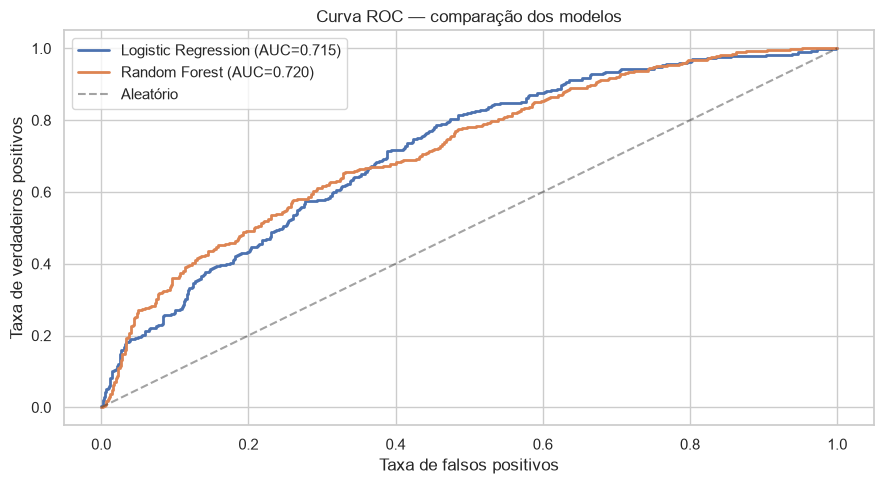

In [92]:

fig, ax = plt.subplots()
for nome, modelo, X_te in [("Logistic Regression", logreg, X_test_scaled), ("Random Forest", rf, X_test)]:
    fpr, tpr, _ = roc_curve(y_test, modelo.predict_proba(X_te)[:, 1])
    auc = roc_auc_score(y_test, modelo.predict_proba(X_te)[:, 1])
    ax.plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aleatório")
ax.set_xlabel("Taxa de falsos positivos")
ax.set_ylabel("Taxa de verdadeiros positivos")
ax.set_title("Curva ROC — comparação dos modelos")
ax.legend()
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ml-curva-roc-logreg-vs-randomforest")
plt.show()


              precision    recall  f1-score   support

   sem risco       0.73      0.64      0.68       559
       risco       0.57      0.67      0.62       404

    accuracy                           0.65       963
   macro avg       0.65      0.65      0.65       963
weighted avg       0.66      0.65      0.65       963



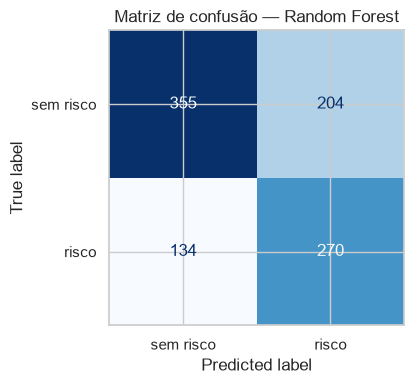

In [80]:
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["sem risco", "risco"]))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=["sem risco", "risco"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão — Random Forest")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ml-matriz-confusao-randomforest")
plt.show()


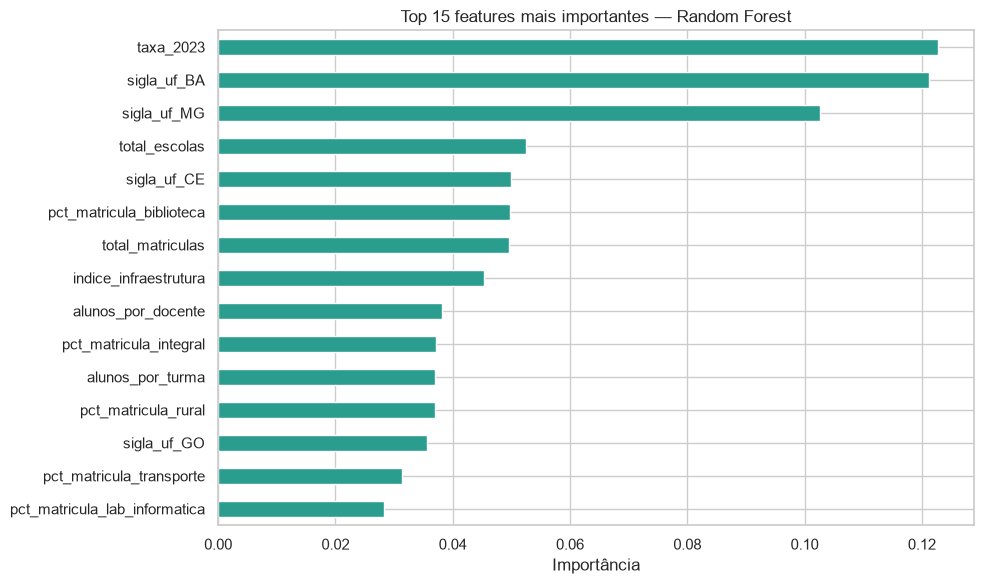

In [81]:
# Importância das features do Random Forest
importancias = (
    pd.Series(
        rf.feature_importances_,
        index=X.columns
    )
    .sort_values(ascending=False)
    .head(15)
)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

importancias.sort_values(ascending=True).plot(
    kind="barh",
    ax=ax,
    color="#2a9d8f"
)

ax.set_title("Top 15 features mais importantes — Random Forest")
ax.set_xlabel("Importância")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "ml-top15-features-importantes-randomforest")
plt.show()

## 5. Clustering — perfis de vulnerabilidade educacional

K-Means sobre as colunas de infraestrutura, sem usar o target — o objetivo é agrupar municípios por perfil estrutural, não prever risco.

In [82]:

FEATURES_CLUSTER = [
    "indice_infraestrutura", "pct_matricula_integral", "pct_matricula_biblioteca",
    "pct_matricula_lab_informatica", "pct_matricula_banda_larga",
    "pct_matricula_esgoto_adequado", "pct_escolas_urbanas",
    "alunos_por_docente", "alunos_por_turma", "pct_matricula_rural",
]

X_cluster = df[FEATURES_CLUSTER].fillna(df[FEATURES_CLUSTER].median())
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)


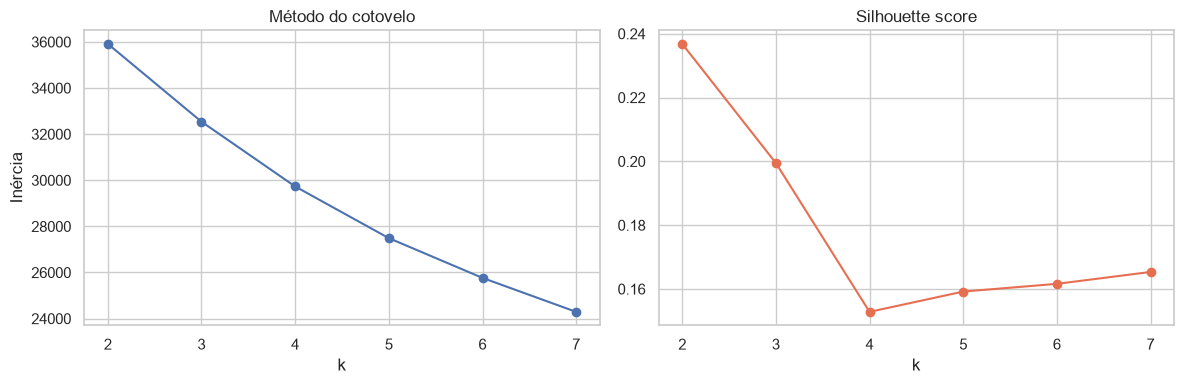

In [93]:

inercia, silhueta = [], []
ks = range(2, 8)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inercia.append(km.inertia_)
    silhueta.append(silhouette_score(X_cluster_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(ks), inercia, marker="o")
ax1.set_title("Método do cotovelo")
ax1.set_xlabel("k")
ax1.set_ylabel("Inércia")

ax2.plot(list(ks), silhueta, marker="o", color="#e76f51")
ax2.set_title("Silhouette score")
ax2.set_xlabel("k")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ml-kmeans-cotovelo-silhouette")
plt.show()


- Escolha final do número de clusters
- K=4 foi adotado após a comparação dos valores de silhouette,
- buscando uma segmentação útil e interpretável dos perfis municipais.
##### **Justificativa:** o número final de clusters foi definido em `K=4` após a comparação das métricas de silhouette para diferentes valores de K. A escolha busca equilibrar qualidade da separação dos grupos e uma segmentação suficientemente útil para a análise dos municípios.

In [85]:

K_FINAL = 4

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

perfil_clusters = df.groupby("cluster")[FEATURES_CLUSTER + ["alvo_taxa_2024"]].mean().round(1)
perfil_clusters["municipios"] = df.groupby("cluster").size()
perfil_clusters

,indice_infraestrutura,pct_matricula_integral,pct_matricula_biblioteca,pct_matricula_lab_informatica,pct_matricula_banda_larga,pct_matricula_esgoto_adequado,pct_escolas_urbanas,alunos_por_docente,alunos_por_turma,pct_matricula_rural,alvo_taxa_2024,municipios
cluster,,,,,,,,,,,,
0,67.7,21.4,48.0,19.5,81.6,60.3,29.5,23.1,24.9,77.7,56.6,956
1,93.4,19.3,86.9,88.5,92.8,92.4,79.3,15.6,20.3,32.3,69.7,1423
2,78.1,15.0,74.9,13.4,90.5,90.2,74.9,15.9,19.9,32.1,67.2,1254
3,64.0,35.6,43.5,15.9,66.7,61.2,28.7,14.3,18.5,85.4,60.3,1178


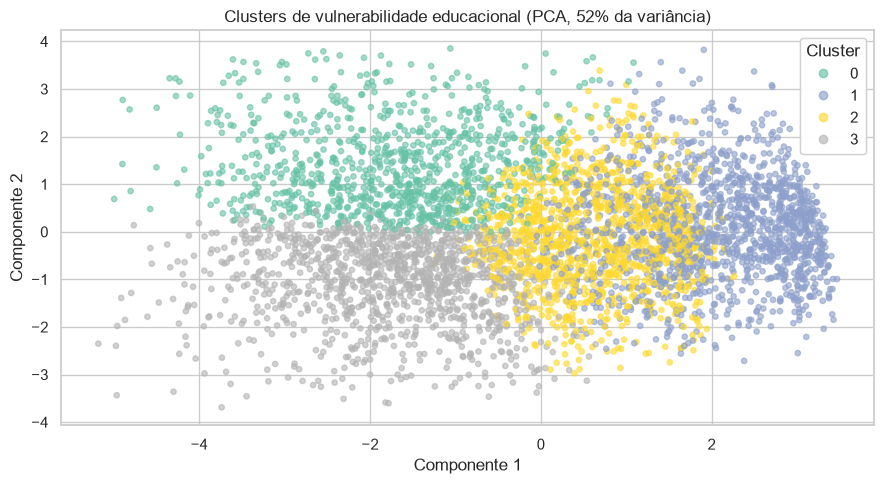

In [86]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster_scaled)

fig, ax = plt.subplots()
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df["cluster"], cmap="Set2", alpha=0.6, s=15)
ax.set_title(f"Clusters de vulnerabilidade educacional (PCA, {pca.explained_variance_ratio_.sum():.0%} da variância)")
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ml-clusters-pca.png")
plt.show()


In [88]:

cruzamento = pd.crosstab(df["cluster"], df["classificacao_trajetoria"], normalize="index").round(2) * 100
cruzamento


classificacao_trajetoria,em_ritmo,meta_atingida,retrocesso,ritmo_insuficiente
cluster,,,,
0,36.0,15.0,36.0,13.0
1,37.0,27.0,29.0,7.0
2,37.0,24.0,31.0,8.0
3,30.0,24.0,34.0,12.0


## 6. Exportando o resultado da modelagem

Gera uma tabela de resultado para consumo analítico, sem alterar a camada Gold.
##### **Nota metodológica:** `prob_risco` é utilizado como **pontuação de priorização** dos municípios após o treinamento do modelo. Como essa aplicação utiliza a base completa, esses valores não devem ser interpretados como uma métrica de desempenho ou validação do modelo. As métricas do modelo são calculadas separadamente sobre o conjunto de teste.


In [89]:
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

resultado = df[["id_municipio", "sigla_uf", "regiao", "classificacao_trajetoria", "cluster"]].copy()
resultado["prob_risco"] = rf.predict_proba(X)[:, 1]
resultado = resultado.sort_values("prob_risco", ascending=False)

OUTPUT_PATH = RESULTS_DIR / "gold_ml_risco_municipio.parquet"
resultado.to_parquet(OUTPUT_PATH, index=False)

# Cópia em CSV, pra consumo direto no Power BI
resultado.to_csv(RESULTS_DIR / "gold_ml_risco_municipio.csv", index=False)

print("Resultado salvo em:", OUTPUT_PATH)
print("Dimensão:", resultado.shape)
resultado.head(10)


Resultado salvo em: C:\Users\devil\fiap-ai-scientist-fase-02_\fiap-ai-scientist-fase-02_\results\gold_ml_risco_municipio.parquet
Dimensão: (4811, 6)


,id_municipio,sigla_uf,regiao,classificacao_trajetoria,cluster,prob_risco
4643,2928901,BA,Nordeste,em_ritmo,0,0.894757
1840,2918407,BA,Nordeste,retrocesso,0,0.889520
3300,2933307,BA,Nordeste,retrocesso,0,0.888303
3273,2925303,BA,Nordeste,retrocesso,0,0.886296
4597,2914000,BA,Nordeste,ritmo_insuficiente,0,0.885976
451,2906105,BA,Nordeste,retrocesso,3,0.882486
3205,2903201,BA,Nordeste,retrocesso,0,0.879538
4595,2913507,BA,Nordeste,retrocesso,3,0.879492
4566,2903706,BA,Nordeste,ritmo_insuficiente,3,0.877071
1787,2902708,BA,Nordeste,ritmo_insuficiente,0,0.877062


## **Visão dos indicadores principais**
> **Nota metodológica:** o RS foi excluído da base de modelagem inteira (célula 16,
> Seção 3), não só desta agregação por UF. Conforme investigado na seção 14 do
> README, a queda de ~20 p.p. no indicador entre 2023-2024 no estado tem
> assinatura de mudança metodológica na fonte (uniforme em 89,6% dos municípios,
> incompatível com aprendizado real), não retrocesso educacional genuíno. Como
> `classificacao_trajetoria` deriva diretamente dessa comparação, treinar o
> modelo com esses rótulos ensinaria uma relação falsa entre "ser do RS" e
> "estar em risco". A exclusão feita na base garante que o modelo de risco, o
> clustering e a agregação abaixo estejam todos livres desse artefato.

In [90]:
risco_uf = (
    resultado
    .groupby("sigla_uf")
    .agg(
        municipios=("id_municipio", "count"),
        probabilidade_media=("prob_risco", "mean")
    )
    .reset_index()
)

# Municípios classificados como risco
risco_por_uf = (
    resultado
    .assign(
        em_risco=lambda d: d["classificacao_trajetoria"].isin(
            ["retrocesso", "ritmo_insuficiente"]
        )
    )
    .groupby("sigla_uf")["em_risco"]
    .sum()
    .reset_index(name="municipios_em_risco")
)

risco_uf = risco_uf.merge(risco_por_uf, on="sigla_uf")
risco_uf["pct_em_risco"] = risco_uf["municipios_em_risco"] / risco_uf["municipios"] * 100
risco_uf = risco_uf.sort_values("pct_em_risco", ascending=False)

display(risco_uf)

,sigla_uf,municipios,probabilidade_media,municipios_em_risco,pct_em_risco
3,BA,394,0.793011,323,81.979695
1,AM,48,0.654101,34,70.833333
11,PA,136,0.661934,89,65.441176
16,RJ,90,0.540325,51,56.666667
15,PR,395,0.546971,208,52.658228
17,RN,139,0.509670,72,51.798561
20,SE,75,0.517269,38,50.666667
2,AP,16,0.566036,8,50.000000
18,RO,52,0.537668,25,48.076923
7,MA,216,0.585951,103,47.685185


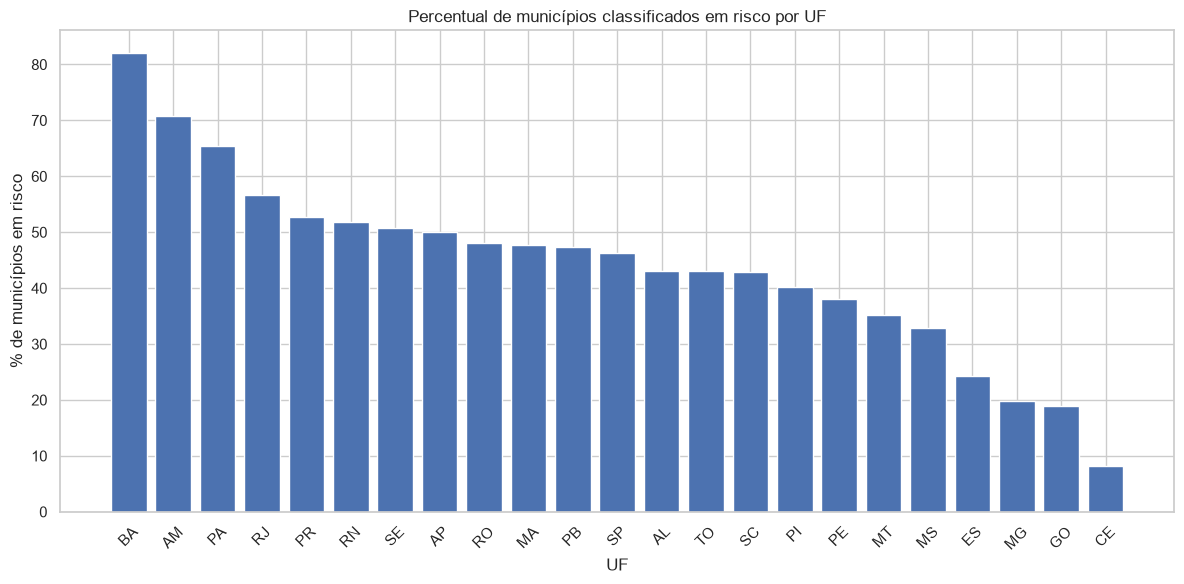

In [91]:
plt.figure(figsize=(12, 6))

plt.bar(
    risco_uf["sigla_uf"],
    risco_uf["pct_em_risco"]
)

plt.title("Percentual de municípios classificados em risco por UF")
plt.xlabel("UF")
plt.ylabel("% de municípios em risco")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(ASSETS_DIR / "ml-percentual-risco-municipios-uf")
plt.show()

## 7. Conclusões

O modelo transformou as informações da Gold numa **classificação de risco por município**, o que dá para avaliar tanto o desempenho do modelo quanto onde o risco está mais concentrado.

- Na base de modelagem, sem o RS, **2.020 dos 4.811 municípios elegíveis (42,0%)** estão em `retrocesso` ou `ritmo_insuficiente` — continua sendo um grupo relevante de atenção até 2030.
- O **Random Forest chegou a AUC-ROC de 0,720 no teste**, perto da Logistic Regression (0,715). Resultado moderado: o modelo separa risco de não-risco, mesmo sem o RS como atalho fácil pra classe de risco.
- Por UF, o quadro não mudou muito: **Bahia segue na frente, com 82,0%** dos municípios em risco, seguida por AM (70,8%) e PA (65,4%). No outro extremo, CE (8,2%), GO (18,9%) e MG (19,7%). São agregações de classificações municipais — não significam que a UF inteira esteja em risco.
- Infraestrutura continua associada ao resultado — municípios nos quartis superiores têm, em média, taxas melhores — mas sozinha não explica tudo.
- O **clustering complementa o modelo**: municípios com o mesmo risco podem ter perfis estruturais bem diferentes, o que ajuda a pensar em priorização.

### Leitura final

O resultado principal não é apontar quem está em risco — é **dar uma forma estruturada de priorizar onde olhar primeiro**, cruzando trajetória, infraestrutura e a probabilidade do modelo. Ele é apoio à decisão, não sentença sobre o desempenho de um município.

> **Observações metodológicas:** duas correções aconteceram no meio do caminho. Removemos `variacao_anual` das features, porque vazava o próprio alvo. E excluímos o RS da base de modelagem inteira, não só da análise por UF — a queda do indicador lá tem assinatura de mudança metodológica na fonte (seção 14 do README), e mantê-lo ensinaria o modelo a ligar "ser do RS" a risco, pelo motivo errado. Nas duas vezes o AUC-ROC caiu depois da correção — sinal de que o número mais alto media artefato, não capacidade real do modelo.

## Ajustes metodológicos finais

- Objetivo apresentado como **classificação de risco associada à trajetória rumo à meta de 2030**.
- `prob_risco` tratado como **pontuação de priorização**, separada das métricas de validação.
- `K=4` documentado como escolha de segmentação dos perfis municipais.
- A análise por UF foi adicionada como **agregação das classificações municipais**.
- **Nenhuma tabela da camada Gold é alterada pelo notebook.**
